In [18]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('wine_data.csv' , header=None , usecols=[0,1,2])
df.columns= ['Class label' , 'Alcohol' , 'Malic Acid']
df.head(5)

,Class label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

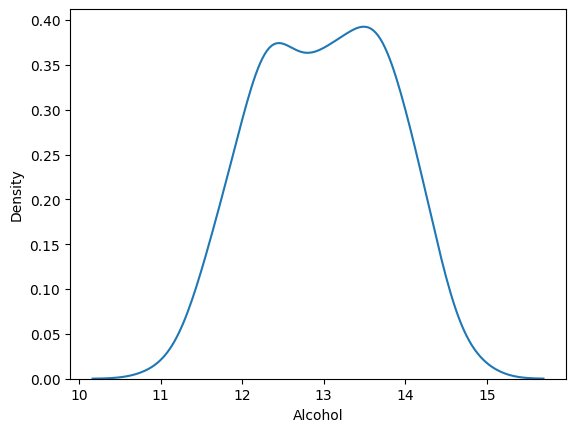

In [19]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

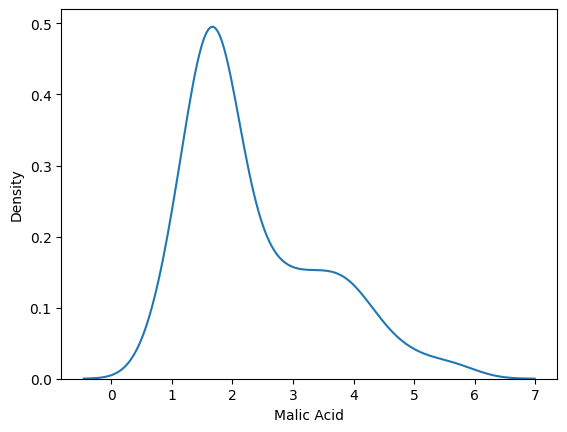

In [20]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

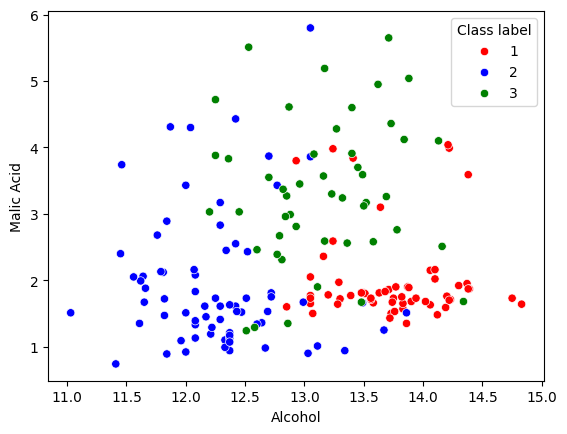

In [21]:
color_dic = {1:'red' , 3:'green' , 2:'blue' }
sns.scatterplot(x =df['Alcohol'] , y =df['Malic Acid'] , hue=df['Class label'] ,palette=color_dic)

# Train Test Split

In [28]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop('Class label' , axis=1) , df['Class label'] , test_size= 0.3 , random_state = 0)
x_train.shape , x_test.shape

((124, 2), (54, 2))

# Normaliaing data by Minmax scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#fit the scalar to train the set , it will learn the parameters
scaler.fit(x_train)
#Transfrom Train and test set 
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [44]:
x_train_scaled = pd.DataFrame(x_train_scaled , columns= x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled , columns= x_test.columns)

In [45]:
np.round(x_train_scaled.describe() , 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [46]:
np.round(x_train.describe() , 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


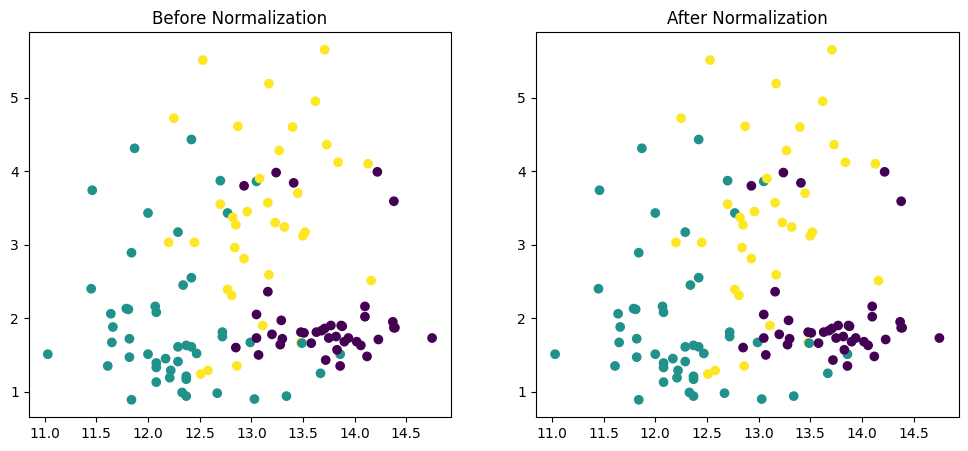

In [47]:
fig , (ax1 , ax2) = plt.subplots(ncols=2 , figsize =(12,5))
ax1.scatter(x_train['Alcohol'] , x_train['Malic Acid'] , c = y_train)
ax1.set_title('Before Normalization')
ax2.scatter(x_train['Alcohol'] , x_train['Malic Acid'] , c =y_train)
ax2.set_title('After Normalization')
plt.show()

<Axes: title={'center': 'After Scaling'}, xlabel='Alcohol', ylabel='Density'>

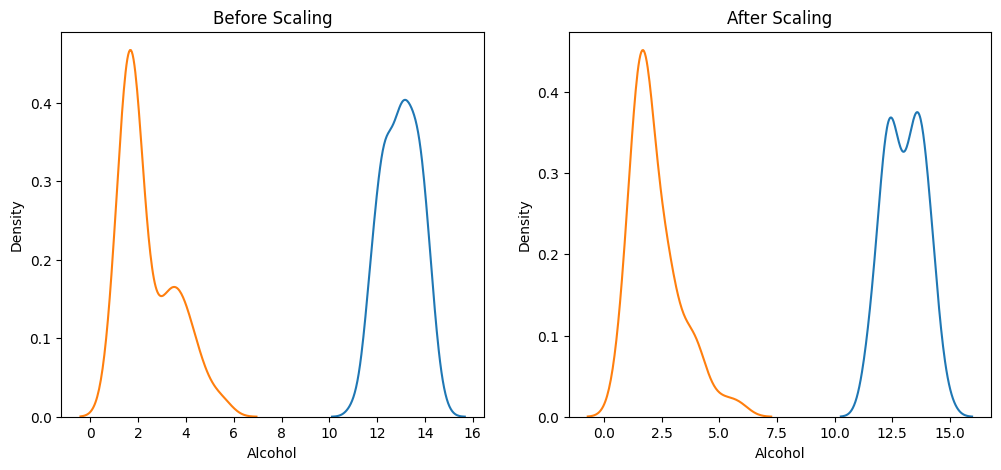

In [48]:
fig , (ax1 , ax2) = plt.subplots(ncols= 2, figsize = (12,5))
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Alcohol'] ,ax=ax1)
sns.kdeplot( x_train['Malic Acid'] , ax=ax1)
ax2.set_title('After Scaling')
sns.kdeplot(x_test['Alcohol'] , ax=ax2)
sns.kdeplot(x_test['Malic Acid'] , ax=ax2)